In [ ]:
import pandas as pd
from tqdm import tqdm
import numpy as np
import cv2
import os
import shutil
import pathlib
import seaborn as sns
import matplotlib.pyplot as plt
from torch.utils.data import Dataset
from torch.utils.data import DataLoader
import torchvision
from torchvision import datasets, models, transforms, utils
#from torchvision.transforms import v2
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.optim import lr_scheduler
from torchvision import models
from torchvision.datasets import ImageFolder
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import random
import torchsummary
from PIL import Image
from pathlib import Path
import pandas as pd
import numpy as np


# Handling images
from PIL import Image
import matplotlib.pyplot as plt

# Handling paths

import time

# Pytorch essentials
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.optim import lr_scheduler
from torchvision import models
from torchvision.datasets import ImageFolder
import torchsummary



# Pytorch essentials for datasets.
from torch.utils.data.sampler import SubsetRandomSampler
from torch.utils.data import Dataset
from torch.utils.data import DataLoader

# Pytorch way of data augmentation.
import torchvision
from torchvision import datasets, models, transforms, utils
#from torchvision.transforms import v2

import cv2
import os
from glob import glob
from tqdm import tqdm
import shutil
from sklearn.model_selection import train_test_split
import seaborn as sns

In [ ]:
df = pd.read_csv('Chest_xray_Corona_Metadata.csv')
df


,Unnamed: 0,X_ray_image_name,Label,Dataset_type,Label_2_Virus_category,Label_1_Virus_category
0,0,IM-0128-0001.jpeg,Normal,TRAIN,NaN,NaN
1,1,IM-0127-0001.jpeg,Normal,TRAIN,NaN,NaN
2,2,IM-0125-0001.jpeg,Normal,TRAIN,NaN,NaN
3,3,IM-0122-0001.jpeg,Normal,TRAIN,NaN,NaN
4,4,IM-0119-0001.jpeg,Normal,TRAIN,NaN,NaN
...,...,...,...,...,...,...
5905,5928,person1637_virus_2834.jpeg,Pnemonia,TEST,NaN,Virus
5906,5929,person1635_virus_2831.jpeg,Pnemonia,TEST,NaN,Virus
5907,5930,person1634_virus_2830.jpeg,Pnemonia,TEST,NaN,Virus
5908,5931,person1633_virus_2829.jpeg,Pnemonia,TEST,NaN,Virus


In [ ]:
df['Label_1_Virus_category'] = df['Label_1_Virus_category'].fillna('Normal')
#drop colums with "Stress-Smoking" 
df = df[df['Label_1_Virus_category'] != 'Stress-Smoking']
mapping = {'Normal': 0, 'Virus': 1, 'bacteria': 2}    

In [ ]:
train_imgs = df[df['Dataset_type'] == 'TRAIN'][['X_ray_image_name', 'Label_1_Virus_category']].copy()
train_imgs['Label_1_Virus_category'] = train_imgs['Label_1_Virus_category'].replace(mapping).astype(int)
train_imgs.rename(columns={'Label_1_Virus_category': 'target'}, inplace=True)
train_imgs.to_csv('train_data.csv', index=False)

test_imgs = df[df['Dataset_type'] == 'TEST'][['X_ray_image_name', 'Label_1_Virus_category']].copy()
test_imgs['Label_1_Virus_category'] = test_imgs['Label_1_Virus_category'].replace(mapping).astype(int)
test_imgs.rename(columns={'Label_1_Virus_category': 'target'}, inplace=True)
test_imgs.to_csv('test_data.csv', index=False)

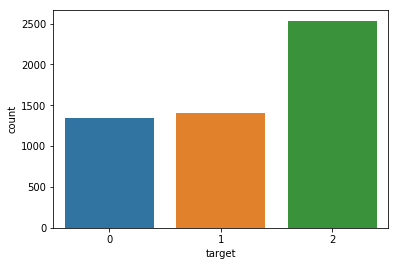

In [6]:
train = pd.read_csv('train_data.csv')
test = pd.read_csv('test_data.csv')

sns.countplot(x = train['target'])
#None = Normal 
#Virus = Pneumonia_Virus 
#Bacteria = Pneumonia_Bacteria

In [ ]:
# Initialize ImageDataGenerator with augmentation & normalization

train['target'] = train['target'].astype(str)

train_gen = ImageDataGenerator(
    rescale=1/255,  # Normalize the image pixel values to [0, 1]
    zoom_range=0.1,  # Random zoom range
    rotation_range=20,  # Random rotation from -20 to +20 degrees
    width_shift_range=0.1,  # Random horizontal shift by 10% of the image width
    shear_range=0.1,  # Shear angle in degrees
    samplewise_center=True,  # Center each image
    samplewise_std_normalization=True  # Normalize each image by subtracting mean and dividing by std deviation
)

# Assuming 'train' is a DataFrame containing the image paths and labels
train_flow = train_gen.flow_from_dataframe(
    dataframe=train,  # Pandas DataFrame with file paths and labels
    directory= 'C:/Users/BT_Lab/Downloads/archive (1)/Coronahack-Chest-XRay-Dataset/Coronahack-Chest-XRay-Dataset/train' ,  # Directory containing the images (adjust the path as needed)
    x_col="X_ray_image_name", 
    y_col='target',  #
    batch_size=32,  
    shuffle=True, 
    class_mode='categorical', 
    target_size=(320, 320)  # Resize images to 320x320 before feeding into the model
)

# Check the class labels
print(train_flow.class_indices)
#train_flow is the training data 

Found 5284 validated image filenames belonging to 3 classes.
{'0': 0, '1': 1, '2': 2}
